# **Welcome to CATNIP**

There are 2 pieces to CATNIP, the python modules and the google sheet. First, make sure your Google Sheet is set up according to the README. This is where important disk information is stored that is read by the python modules. Once your Google Sheet is ready, we can begin.

## Linking to the Google Sheet

In [1]:
# Directory where python modules are located
moduledir = '/Users/piperlentz/Amherst/Fall 2025/Thesis/DiskSample/catnip/FIGG_CATNIP/modules'

# Directory where your .fits files (images) are located
datadir = '/Users/piperlentz/Amherst/Fall 2025/Thesis/DiskSample'

# URL of your spreadsheet interface
wburl = 'https://docs.google.com/spreadsheets/d/1RLC65_24kCbI1xdAq-S674qjsBXGGn9l_U9dS0wgT1A/edit?gid=0#gid=0'

# Whether to pip install bettermoments and photutils
pip_install = False

In [2]:
# Authorizing google credentials to open google sheet

import gspread
from oauth2client.service_account import ServiceAccountCredentials

# Define the scope and authorize
# Your .json file must be in the same directory as this tutorial
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("figgcatnip-interface.json", scope)
gc = gspread.authorize(creds)


## Importing Python Modules

In [3]:
# Import the modules
import sys
sys.path.append(moduledir)
import sheetreader
import catnip
from imp import reload
reload(sheetreader)
reload(catnip)

<module 'catnip' from '/Users/piperlentz/Amherst/Fall 2025/Thesis/DiskSample/catnip/FIGG_CATNIP/modules/catnip.py'>

## Reading the Google Sheet

In [4]:
# Read sheet and save the data and display dicts
wb = gc.open_by_url(wburl)
master_dict = sheetreader.wb_to_dict(wb, 'Image Data', add_paths=False, settings_sheet='Image Settings', namekey='Tracer', splitkey='Object')
master_display_dict = sheetreader.wb_to_dict(wb, 'Disk Information', settings_sheet='Disk Settings')

## Creating a dictionary for AstroObjects

In [5]:
astro_objects = {}
disk_lst = [disk for disk in master_display_dict if master_display_dict[disk]['Use?']]
for disk in disk_lst:
    astro_objects[disk] = catnip.AstroObject(disk, master_dict[disk], master_display_dict[disk])

AS 209
512.5 512.5


Processing EM* AS 209: 100%|██████████████████████| 2/2 [00:00<00:00, 11.31it/s]


Current image: EM* AS 209 scattered light
Rotating over PAs...
Generating radial profiles...
0       0.57172
30     0.451176
60     0.499985
90     1.553263
120    2.574728
150    3.439411
180    4.076359
210    2.896817
240    1.723152
270    0.712098
300    0.904987
330    0.991908
0       0.57172
90     1.553263
Name: 1, dtype: object
[np.float64(3.0037564825144654)]
0.1
0       1.289818
30      2.729631
60      7.704961
90     10.981863
120    16.930095
150    22.253015
180     18.82054
210     9.202629
240     2.401491
270     0.996143
300     0.733411
330     0.806226
0       1.289818
90     10.981863
Name: 2, dtype: object
[np.float64(18.813604283919286)]
0.1
0       7.655212
30     12.023498
60     13.299788
90        7.2664
120    10.081307
150    13.933994
180    16.302452
210      7.58625
240     5.596737
270     4.018227
300     3.513968
330     4.412504
0       7.655212
90        7.2664
Name: 3, dtype: object
[np.float64(9.293866880795704)]
0.1
0       5.919198
30      7.4

In [8]:
# Use this cell to update display dict info without reprocessing
# don't have to run the whole notebook over again
wb = gc.open_by_url(wburl)
master_display_dict = sheetreader.wb_to_dict(wb, 'Disk Information', settings_sheet='Disk Settings')
disk_lst = [disk for disk in master_display_dict if master_display_dict[disk]['Use?']]
for disk in disk_lst: astro_objects[disk].update(master_display_dict[disk])

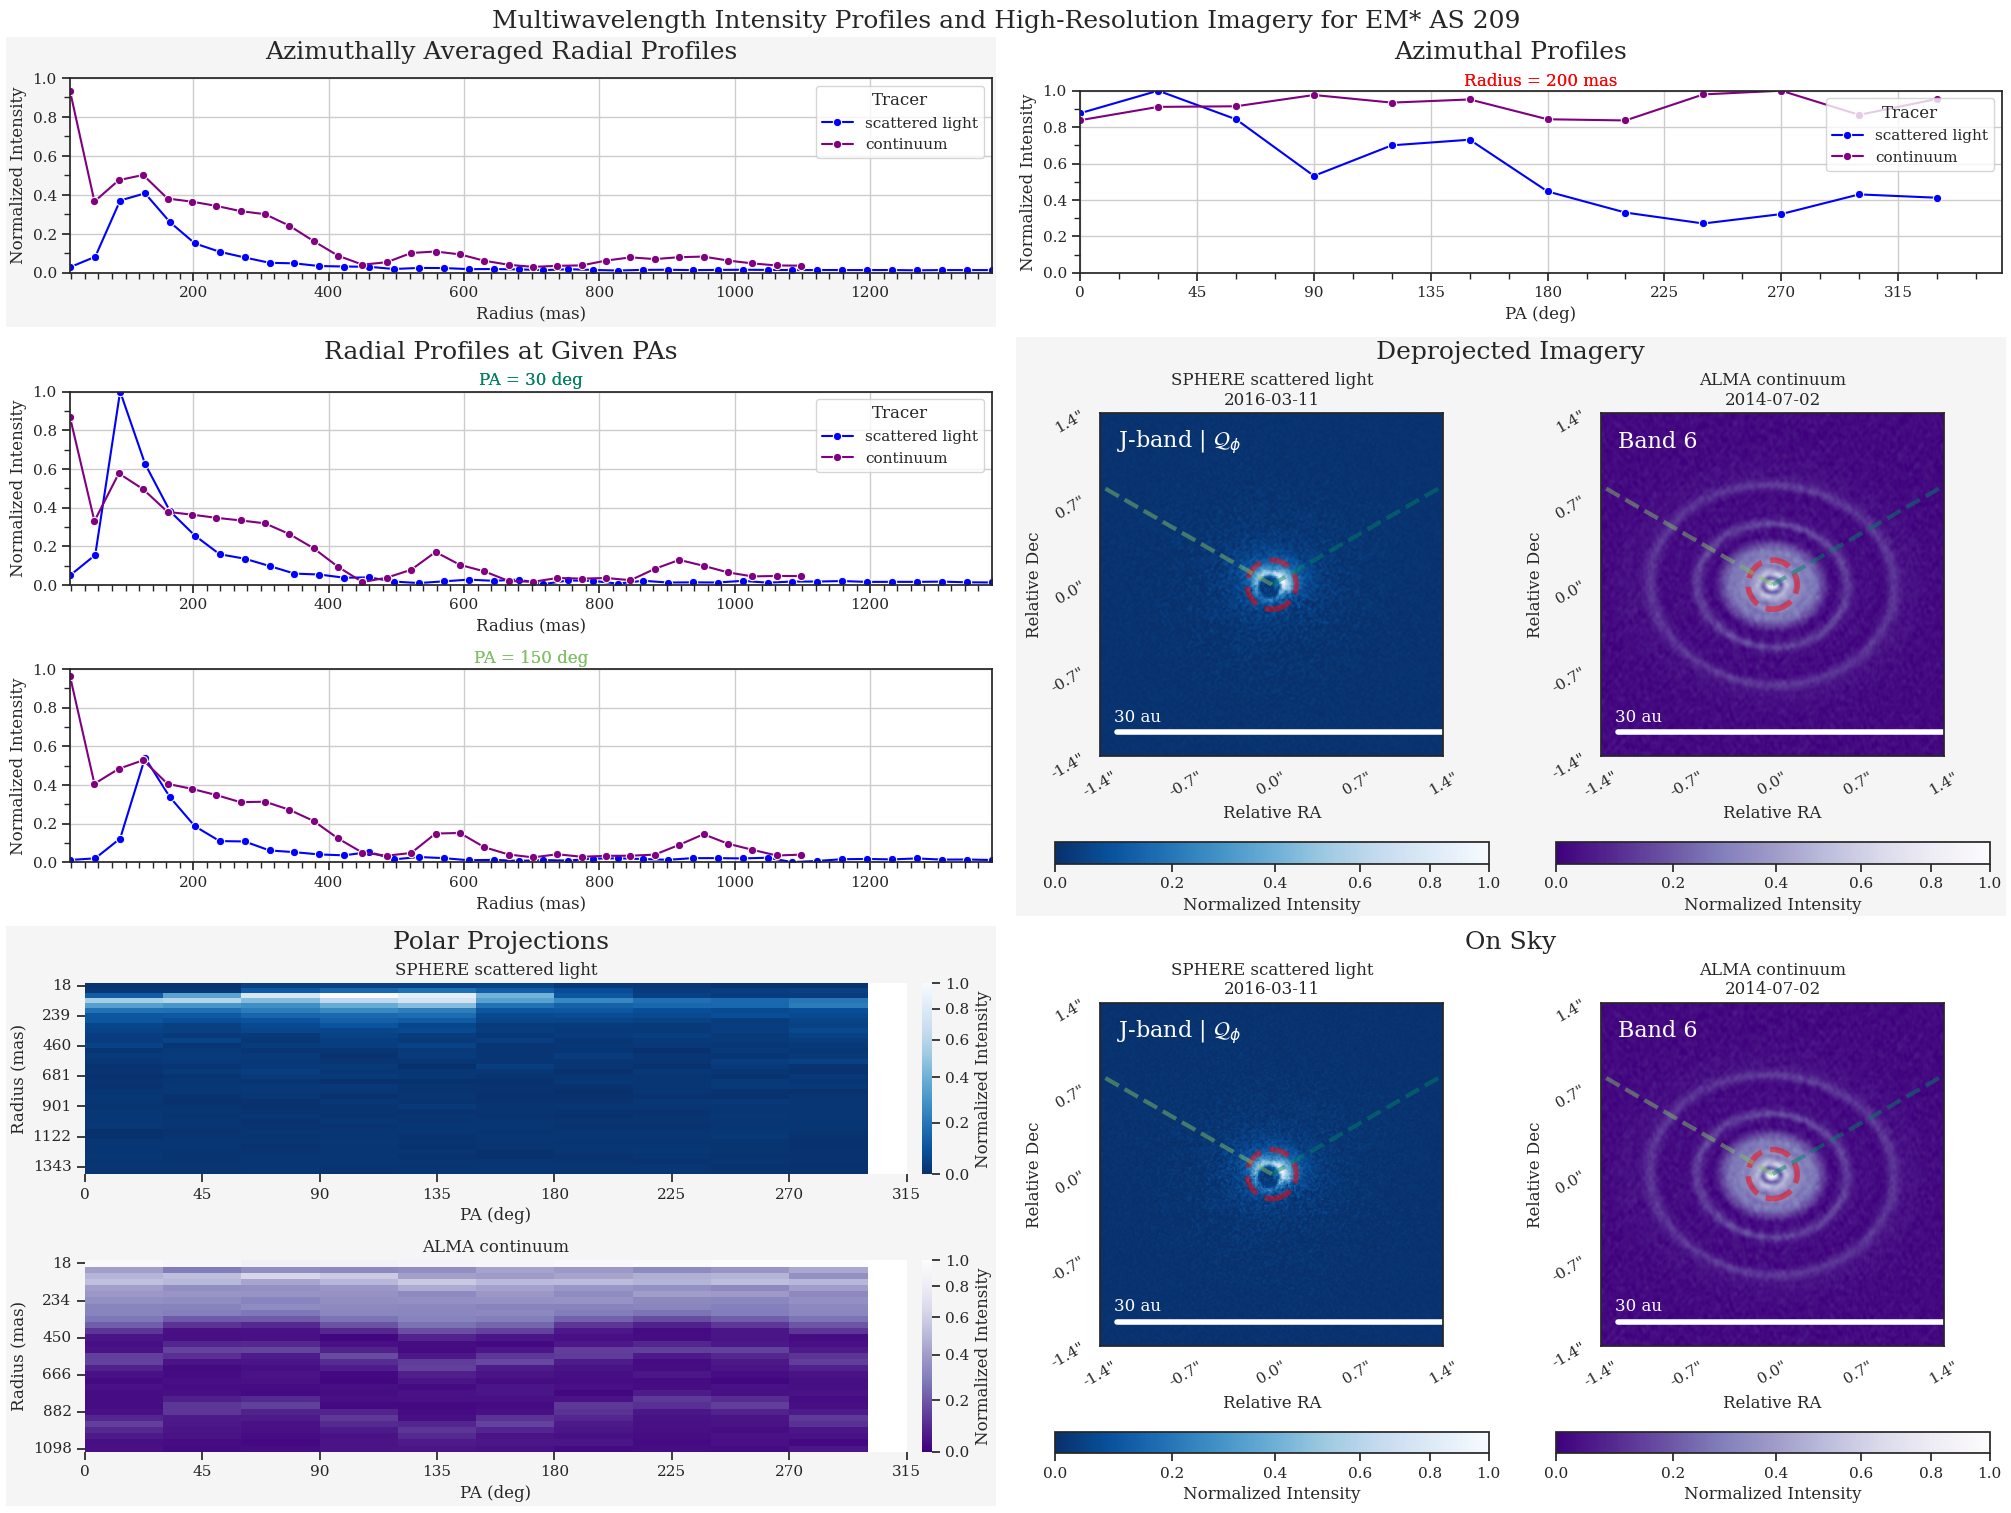

In [9]:
# Plot profiles and images for your desired disks
for disk in disk_lst: astro_objects[disk].make_plot_multiline()